# Comorbidity Graph Evaluation

End-to-end pipeline: load predictions & MIMIC data, build comorbidity graph, score guided (SAE) vs naive (Delphi), and visualise results.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from comorbidity_graph.ingest.load_predictions import load_predictions
from comorbidity_graph.ingest.load_comorbidity import (
    load_mimic_diagnoses,
    build_incidence_matrix,
)
from comorbidity_graph.graph.build_cooccurrence import build_cooccurrence
from comorbidity_graph.graph.build_distance import build_distance, build_distance_matrix
from comorbidity_graph.score.score_topk import score_topk
from comorbidity_graph.evaluation.per_example import build_per_example
from comorbidity_graph.evaluation.aggregate import aggregate

## Configuration

Edit this cell to point at your data. Defaults work with the MIMIC-IV demo subset.

In [3]:
DATA_DIR = Path("../data")
MIMIC_PATH = None  # None -> uses demo file in DATA_DIR

# Smoothing parameters for distance computation
ALPHA = 1.0
BETA = 2.0

## 1. Load predictions

In [4]:
preds = load_predictions(DATA_DIR)
print(f"Predictions: {len(preds)} rows, {preds['perturbed_code'].nunique()} perturbed codes")
print(f"Methods: {preds['method'].unique().tolist()}")
print(f"Sets: {preds['set'].unique().tolist()}")
preds.head()

Predictions: 960 rows, 32 perturbed codes
Methods: ['SAE', 'Delphi']
Sets: ['matched_control', 'separate_control']


,row_key,set,method,role,steer_mode,perturbed_code,perturbed_desc,perturbed_chapter,specificity,rank,pred_token,pred_code,pred_description,pred_shift,is_disease,category
0,matched_control|J22 Unspecified acute lower re...,matched_control,SAE,guided,set_to_case,J22,Unspecified acute lower respiratory infection,X. Respiratory Diseases,11.169779,1,Q01 Encephalocele,Q01,Encephalocele,-1.819787,True,icd10
1,matched_control|J22 Unspecified acute lower re...,matched_control,SAE,guided,set_to_case,J22,Unspecified acute lower respiratory infection,X. Respiratory Diseases,11.169779,2,O88 Obstetric embolism,O88,Obstetric embolism,-1.775238,True,icd10
2,matched_control|J22 Unspecified acute lower re...,matched_control,SAE,guided,set_to_case,J22,Unspecified acute lower respiratory infection,X. Respiratory Diseases,11.169779,3,B87 Myiasis,B87,Myiasis,-1.667191,True,icd10
3,matched_control|J22 Unspecified acute lower re...,matched_control,SAE,guided,set_to_case,J22,Unspecified acute lower respiratory infection,X. Respiratory Diseases,11.169779,4,H32 Chorioretinal disorders in diseases classi...,H32,Chorioretinal disorders in diseases classified...,-1.542633,True,icd10
4,matched_control|J22 Unspecified acute lower re...,matched_control,SAE,guided,set_to_case,J22,Unspecified acute lower respiratory infection,X. Respiratory Diseases,11.169779,5,A88 Other viral infections of central nervous ...,A88,Other viral infections of central nervous syst...,-1.471056,True,icd10


## 2. Build comorbidity graph

In [5]:
mimic = load_mimic_diagnoses(path=MIMIC_PATH, data_dir=DATA_DIR)
incidence, patients, codes = build_incidence_matrix(mimic)
N, prevalence, cooc = build_cooccurrence(incidence, codes)
edges = build_distance(N, prevalence, cooc, alpha=ALPHA, beta=BETA)
dist_matrix = build_distance_matrix(edges, codes, N=N, alpha=ALPHA, beta=BETA)

print(f"MIMIC: {len(patients)} patients, {len(codes)} ICD-10 codes")
print(f"Co-occurrence: {len(cooc)} edges")
print(f"Distance matrix: {dist_matrix.shape[0]}x{dist_matrix.shape[1]}")

# Coverage
pred_codes = set(preds.loc[preds["is_disease"], "pred_code"].unique())
perturbed_codes = set(preds["perturbed_code"].unique())
graph_codes = set(dist_matrix.index)
print(f"\nPredicted codes in graph: {len(pred_codes & graph_codes)}/{len(pred_codes)}")
print(f"Perturbed codes in graph: {len(perturbed_codes & graph_codes)}/{len(perturbed_codes)}")

MIMIC: 44 patients, 379 ICD-10 codes
Co-occurrence: 18162 edges
Distance matrix: 379x379

Predicted codes in graph: 22/332
Perturbed codes in graph: 26/32


## 3. Score predictions

In [6]:
scored = score_topk(preds, dist_matrix)
print(f"Scored: {len(scored)} rows")
scored.head(10)

Scored: 96 rows


,row_key,role,steer_mode,perturbed_code,score_unsigned,effective_k_unsigned,score_sign_aware,effective_k_sign_aware,score_magnitude,effective_k_magnitude
0,matched_control|J22 Unspecified acute lower re...,guided,set_to_case,J22,NaN,0,NaN,0,NaN,0
1,matched_control|M79 Other soft tissue disorder...,guided,set_to_case,M79,NaN,0,NaN,0,NaN,0
2,matched_control|I50 Heart failure,guided,set_to_case,I50,NaN,0,NaN,0,NaN,0
3,matched_control|N18 Chronic renal failure,guided,set_to_case,N18,NaN,0,NaN,0,NaN,0
4,matched_control|M81 Osteoporosis without patho...,guided,set_to_case,M81,3.828641,1,3.828641,1,3.828641,1
5,matched_control|I48 Atrial fibrillation and fl...,guided,set_to_case,I48,3.828641,1,NaN,0,3.828641,1
6,matched_control|L98 Other disorders of skin an...,guided,set_to_case,L98,NaN,0,NaN,0,NaN,0
7,matched_control|K44 Diaphragmatic hernia,guided,set_to_case,K44,NaN,0,NaN,0,NaN,0
8,matched_control|K29 Gastritis and duodenitis,guided,set_to_case,K29,NaN,0,NaN,0,NaN,0
9,matched_control|K21 Gastro-oesophageal reflux ...,guided,set_to_case,K21,NaN,0,NaN,0,NaN,0


## 4. Per-example evaluation

In [7]:
per_ex = build_per_example(scored)
print(f"Per-example: {len(per_ex)} paired comparisons")
per_ex

Per-example: 48 paired comparisons


,row_key,steer_mode,perturbed_code,guided_score_unsigned,naive_score_unsigned,delta_unsigned,guided_effective_k_unsigned,naive_effective_k_unsigned,winner_unsigned,guided_score_sign_aware,...,delta_sign_aware,guided_effective_k_sign_aware,naive_effective_k_sign_aware,winner_sign_aware,guided_score_magnitude,naive_score_magnitude,delta_magnitude,guided_effective_k_magnitude,naive_effective_k_magnitude,winner_magnitude
0,matched_control|J22 Unspecified acute lower re...,set_to_case,J22,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
1,matched_control|M79 Other soft tissue disorder...,set_to_case,M79,NaN,3.828641,NaN,0,1,na,NaN,...,NaN,0,1,na,NaN,3.828641,NaN,0,1,na
2,matched_control|I50 Heart failure,set_to_case,I50,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
3,matched_control|N18 Chronic renal failure,set_to_case,N18,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
4,matched_control|M81 Osteoporosis without patho...,set_to_case,M81,3.828641,3.828641,0.000000,1,1,tie,3.828641,...,NaN,1,0,na,3.828641,3.828641,-4.440892e-16,1,1,guided
5,matched_control|I48 Atrial fibrillation and fl...,set_to_case,I48,3.828641,2.442347,1.386294,1,1,naive,NaN,...,NaN,0,1,na,3.828641,2.442347,1.386294e+00,1,1,naive
6,matched_control|L98 Other disorders of skin an...,set_to_case,L98,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
7,matched_control|K44 Diaphragmatic hernia,set_to_case,K44,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
8,matched_control|K29 Gastritis and duodenitis,set_to_case,K29,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na
9,matched_control|K21 Gastro-oesophageal reflux ...,set_to_case,K21,NaN,NaN,NaN,0,0,na,NaN,...,NaN,0,0,na,NaN,NaN,NaN,0,0,na


## 5. Aggregate statistics

In [8]:
summaries = aggregate(per_ex)

print("Overall")
display(summaries["overall"])

print("\nBy steer mode")
display(summaries["by_steer_mode"])

Overall


,variant,n_valid,n_invalid,mean_guided_score,mean_naive_score,mean_delta,median_delta,std_delta,guided_win_rate,naive_win_rate,tie_rate,mean_guided_effective_k,mean_naive_effective_k,wilcoxon_stat,wilcoxon_pval
0,unsigned,9,39,3.544067,3.520576,0.023491,0.000000e+00,0.678597,0.333333,0.222222,0.444444,1.333333,1.111111,NaN,NaN
1,sign_aware,5,43,3.510836,3.828641,-0.317805,0.000000e+00,0.538238,0.400000,0.000000,0.600000,1.400000,1.000000,NaN,NaN
2,magnitude,9,39,3.548056,3.520576,0.027480,-4.440892e-16,0.675406,0.555556,0.333333,0.111111,1.333333,1.111111,NaN,NaN



By steer mode


,index,variant,n_valid,n_invalid,mean_guided_score,mean_naive_score,mean_delta,median_delta,std_delta,guided_win_rate,naive_win_rate,tie_rate,mean_guided_effective_k,mean_naive_effective_k,wilcoxon_stat,wilcoxon_pval
0,0,unsigned,5,25,3.551383,3.274124,0.277259,0.000000,0.790309,0.20,0.40,0.4,1.00,1.2,NaN,NaN
1,1,sign_aware,1,29,3.828641,3.828641,0.000000,0.000000,NaN,0.00,0.00,1.0,1.00,1.0,NaN,NaN
2,2,magnitude,5,25,3.551383,3.274124,0.277259,0.000000,0.790309,0.40,0.40,0.2,1.00,1.2,NaN,NaN
3,0,unsigned,4,14,3.534922,3.828641,-0.293719,-0.173287,0.392052,0.50,0.00,0.5,1.75,1.0,NaN,NaN
4,1,sign_aware,4,14,3.431385,3.828641,-0.397257,-0.173287,0.586672,0.50,0.00,0.5,1.50,1.0,NaN,NaN
5,2,magnitude,4,14,3.543898,3.828641,-0.284743,-0.159829,0.386930,0.75,0.25,0.0,1.75,1.0,NaN,NaN


## 6. Plots

### 6.1 Mean score: guided vs naive by variant

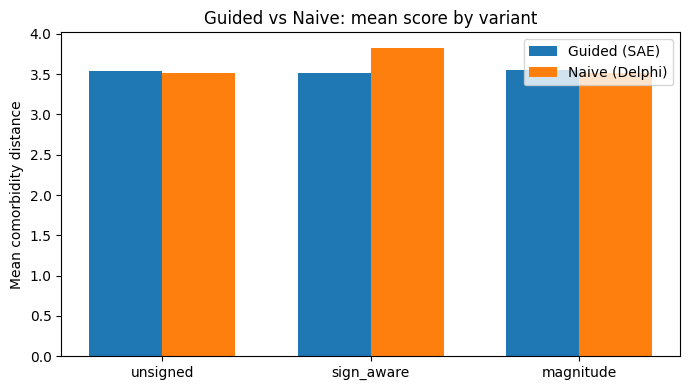

In [9]:
overall = summaries["overall"]
variants = overall["variant"].values
x = np.arange(len(variants))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, overall["mean_guided_score"], w, label="Guided (SAE)")
ax.bar(x + w / 2, overall["mean_naive_score"], w, label="Naive (Delphi)")
ax.set_xticks(x)
ax.set_xticklabels(variants)
ax.set_ylabel("Mean comorbidity distance")
ax.set_title("Guided vs Naive: mean score by variant")
ax.legend()
fig.tight_layout()
plt.show()

### 6.2 Paired scatter: guided vs naive per disease

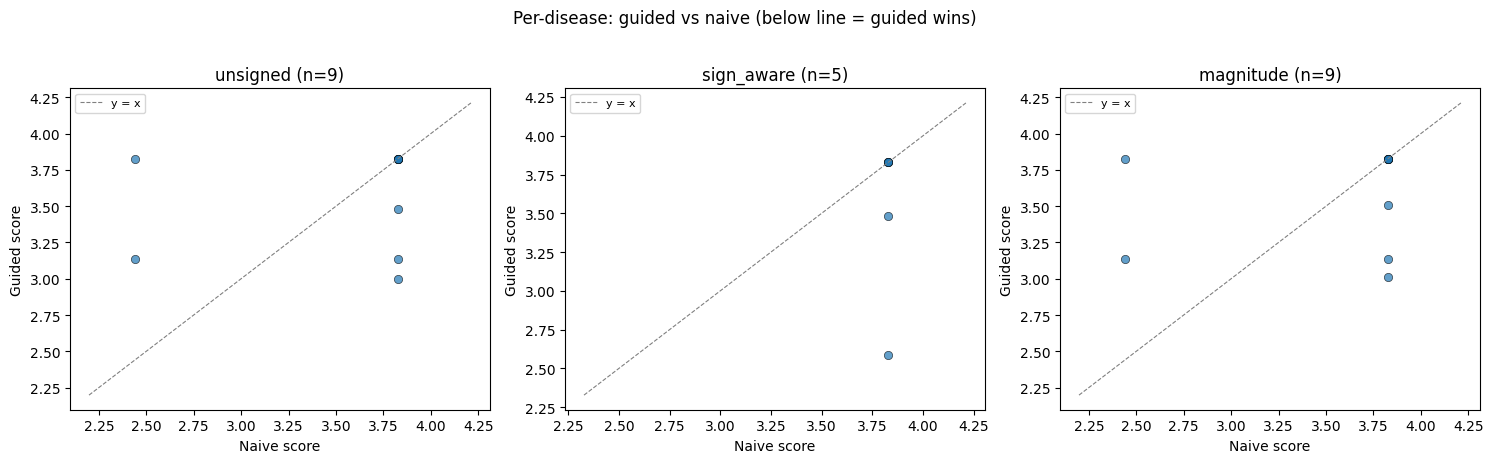

In [10]:
VARIANTS = ["unsigned", "sign_aware", "magnitude"]

fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 4.5))
if len(VARIANTS) == 1:
    axes = [axes]

for ax, v in zip(axes, VARIANTS):
    g_col, n_col = f"guided_score_{v}", f"naive_score_{v}"
    valid = per_ex.dropna(subset=[g_col, n_col])
    if valid.empty:
        ax.set_title(f"{v} (no valid pairs)")
        continue

    ax.scatter(valid[n_col], valid[g_col], alpha=0.7, edgecolors="k", linewidths=0.5)
    lo = min(valid[n_col].min(), valid[g_col].min()) * 0.9
    hi = max(valid[n_col].max(), valid[g_col].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], "--", color="grey", linewidth=0.8, label="y = x")
    ax.set_xlabel("Naive score")
    ax.set_ylabel("Guided score")
    ax.set_title(f"{v} (n={len(valid)})")
    ax.legend(fontsize=8)

fig.suptitle("Per-disease: guided vs naive (below line = guided wins)", y=1.02)
fig.tight_layout()
plt.show()

### 6.3 Delta distribution per variant

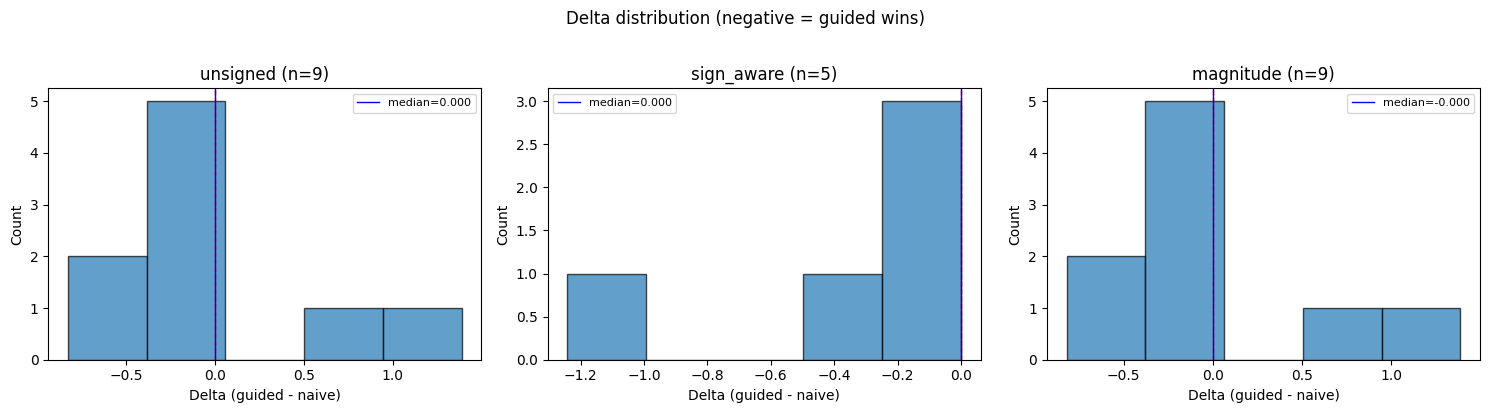

In [11]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 4))
if len(VARIANTS) == 1:
    axes = [axes]

for ax, v in zip(axes, VARIANTS):
    deltas = per_ex[f"delta_{v}"].dropna()
    if deltas.empty:
        ax.set_title(f"{v} (no data)")
        continue

    ax.hist(deltas, bins=max(5, len(deltas) // 3), edgecolor="k", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.axvline(deltas.median(), color="blue", linestyle="-", linewidth=1, label=f"median={deltas.median():.3f}")
    ax.set_xlabel("Delta (guided - naive)")
    ax.set_ylabel("Count")
    ax.set_title(f"{v} (n={len(deltas)})")
    ax.legend(fontsize=8)

fig.suptitle("Delta distribution (negative = guided wins)", y=1.02)
fig.tight_layout()
plt.show()

### 6.4 Win rate by steer mode

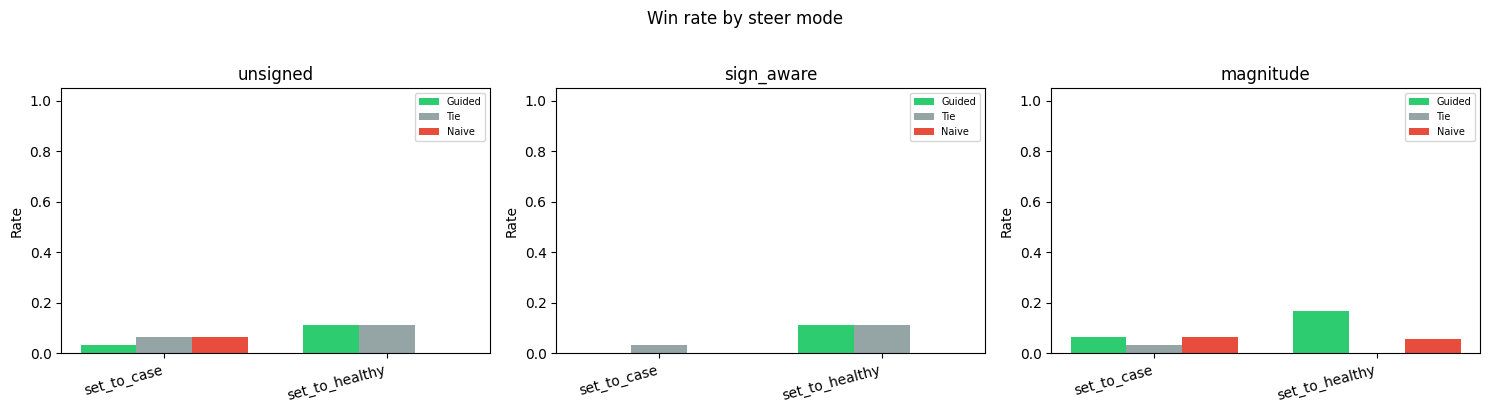

In [12]:
# Compute win rates directly from per_ex (by_steer_mode loses the group key)
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 4))
if len(VARIANTS) == 1:
    axes = [axes]

for ax, v in zip(axes, VARIANTS):
    winner_col = f"winner_{v}"
    counts = (
        per_ex.groupby("steer_mode")[winner_col]
        .value_counts()
        .unstack(fill_value=0)
    )
    # Normalize to rates
    rates = counts.div(counts.sum(axis=1), axis=0)
    mode_labels = rates.index.tolist()
    x = np.arange(len(mode_labels))
    w = 0.25

    for offset, outcome, color in [
        (-w, "guided", "#2ecc71"),
        (0, "tie", "#95a5a6"),
        (w, "naive", "#e74c3c"),
    ]:
        vals = rates[outcome].values if outcome in rates.columns else np.zeros(len(x))
        ax.bar(x + offset, vals, w, label=outcome.capitalize(), color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(mode_labels, rotation=15, ha="right")
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{v}")
    ax.legend(fontsize=7)

fig.suptitle("Win rate by steer mode", y=1.02)
fig.tight_layout()
plt.show()

### 6.5 Distance matrix heatmap (perturbed codes subset)

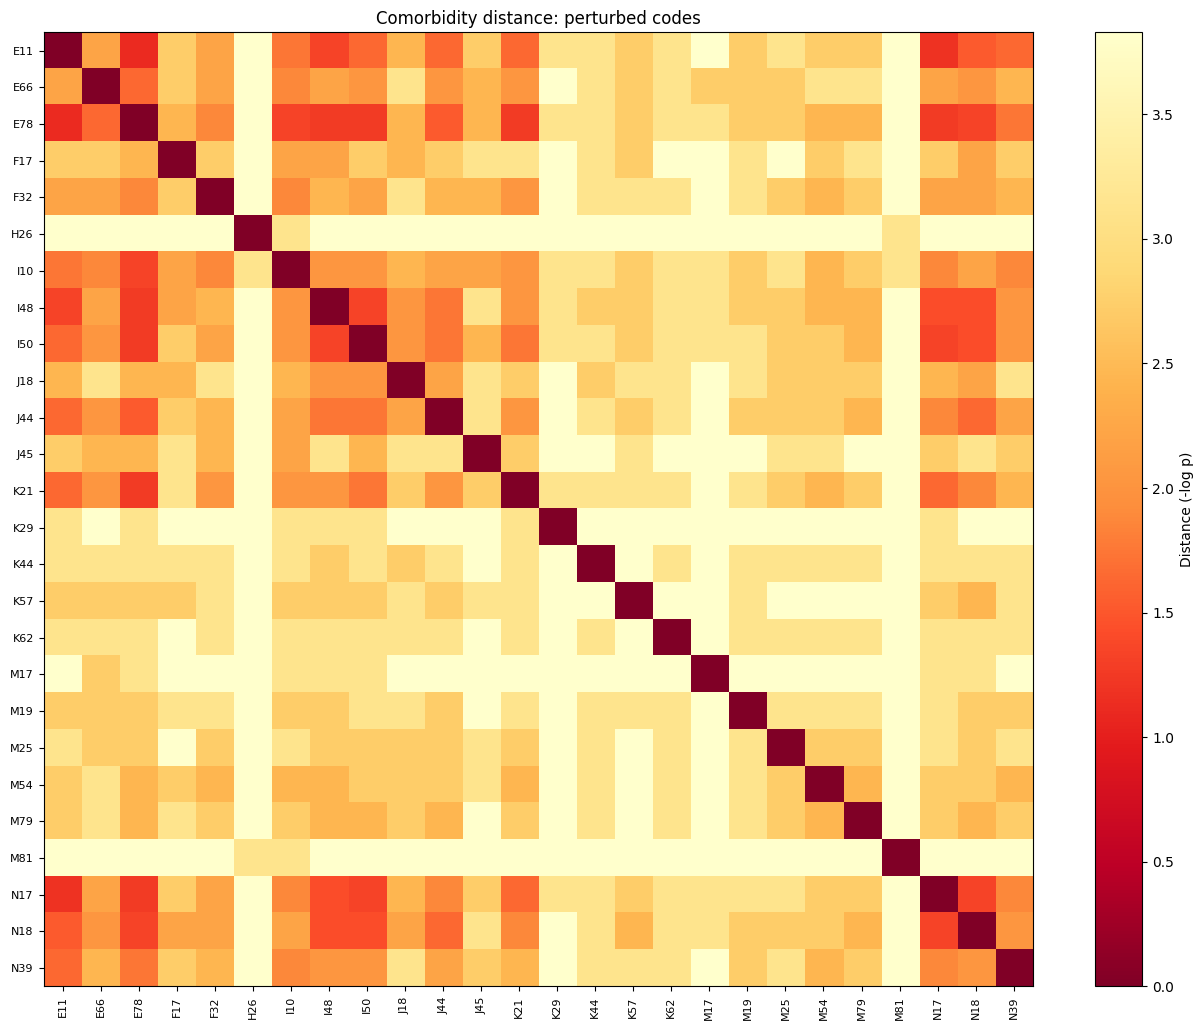

In [13]:
# Show distance sub-matrix for perturbed codes that exist in the graph
available = sorted(perturbed_codes & graph_codes)
if available:
    sub = dist_matrix.loc[available, available]
    fig, ax = plt.subplots(figsize=(max(6, len(available) * 0.5), max(5, len(available) * 0.4)))
    im = ax.imshow(sub.values, cmap="YlOrRd_r", aspect="auto")
    ax.set_xticks(range(len(available)))
    ax.set_xticklabels(available, rotation=90, fontsize=8)
    ax.set_yticks(range(len(available)))
    ax.set_yticklabels(available, fontsize=8)
    fig.colorbar(im, ax=ax, label="Distance (-log p)")
    ax.set_title("Comorbidity distance: perturbed codes")
    fig.tight_layout()
    plt.show()
else:
    print("No perturbed codes found in the distance matrix.")